<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
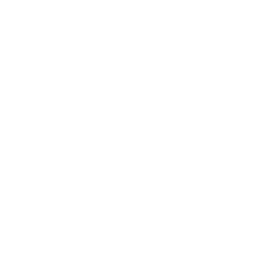
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Molekylær subtypeklassifikation ud fra genekspression</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotek / Genomisk onkologi &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Sammenfatning for ledelsen

Klassificér tumorbiopsiprøver i fire molekylære subtyper (Luminal-A, Luminal-B, HER2-beriget, Basal-lignende) ved hjælp af biomarkørpaneler for genekspression. Anvend kanonisk diskriminantanalyse til at reducere det højdimensionelle ekspressionsrum til fortolkelige variationsakser. Brug MANOVA til at teste, om de gennemsnitlige ekspressionsprofiler adskiller sig signifikant mellem subtyperne. Krydsvalidér for at estimere klassifikationens pålidelighed til klinisk beslutningsstøtte ved valg af behandlingsforløb.

## Datakilder

| Kilde | Beskrivelse | Antal poster |
|--------|-------------|--------|
| WORK.GENE_EXPR | Tumorgenekspression med subtypeetiketter | 100 |
| WORK.NEW_BIOPSIES | Uklassificerede biopsiprøver | 100 |


---

In [1]:
/* --------------------------------------------------------
   Generér syntetisk genekspressionsdatasæt
   med fire molekylære subtyper
   -------------------------------------------------------- */
data work.gene_expr;
    CALL streaminit(42);
    LÆNGDE mol_subtype $12;
    TABEL subtype_list[4] $12 _temporary_ ('LUMINAL_A' 'LUMINAL_B' 'HER2_ENRICH' 'BASAL_LIKE');
    GØR sample_id = 1 TIL 100;
        tumor_id = cat('TUM-', SKRIV_V(sample_id, z5.));
        sub_idx = int(rand('uniform') * 4) + 1;
        mol_subtype = subtype_list[sub_idx];

        /* Simulerede genekspressionsmarkører (log2-skala) */
        VÆLG (mol_subtype);
            NÅR ('LUMINAL_A') GØR;
                esr1_expr = round(rand('normal', 11.5, 1.2), 0.01);
                pgr_expr = round(rand('normal', 9.8, 1.5), 0.01);
                erbb2_expr = round(rand('normal', 7.2, 0.9), 0.01);
                ki67_expr = round(rand('normal', 6.0, 1.0), 0.01);
                egfr_expr = round(rand('normal', 6.5, 1.1), 0.01);
                cytokeratin5 = round(rand('normal', 5.0, 0.8), 0.01);
                tp53_mut_load = round(rand('poisson', 1.5), 1);
                prolif_score = round(rand('normal', 3.2, 0.8), 0.01);
            SLUT;
            NÅR ('LUMINAL_B') GØR;
                esr1_expr = round(rand('normal', 10.0, 1.4), 0.01);
                pgr_expr = round(rand('normal', 7.5, 1.8), 0.01);
                erbb2_expr = round(rand('normal', 8.5, 1.2), 0.01);
                ki67_expr = round(rand('normal', 8.5, 1.2), 0.01);
                egfr_expr = round(rand('normal', 7.0, 1.0), 0.01);
                cytokeratin5 = round(rand('normal', 5.5, 0.9), 0.01);
                tp53_mut_load = round(rand('poisson', 3.0), 1);
                prolif_score = round(rand('normal', 6.0, 1.0), 0.01);
            SLUT;
            NÅR ('HER2_ENRICH') GØR;
                esr1_expr = round(rand('normal', 6.5, 1.5), 0.01);
                pgr_expr = round(rand('normal', 5.0, 1.2), 0.01);
                erbb2_expr = round(rand('normal', 13.0, 1.0), 0.01);
                ki67_expr = round(rand('normal', 9.0, 1.3), 0.01);
                egfr_expr = round(rand('normal', 8.5, 1.2), 0.01);
                cytokeratin5 = round(rand('normal', 6.0, 1.0), 0.01);
                tp53_mut_load = round(rand('poisson', 5.0), 1);
                prolif_score = round(rand('normal', 7.5, 1.1), 0.01);
            SLUT;
            NÅR ('BASAL_LIKE') GØR;
                esr1_expr = round(rand('normal', 4.5, 1.3), 0.01);
                pgr_expr = round(rand('normal', 3.8, 1.0), 0.01);
                erbb2_expr = round(rand('normal', 6.0, 1.1), 0.01);
                ki67_expr = round(rand('normal', 10.5, 1.4), 0.01);
                egfr_expr = round(rand('normal', 11.0, 1.3), 0.01);
                cytokeratin5 = round(rand('normal', 10.5, 1.2), 0.01);
                tp53_mut_load = round(rand('poisson', 7.0), 1);
                prolif_score = round(rand('normal', 8.8, 1.2), 0.01);
            SLUT;
            ELLERS_OM;
        SLUT;
        UDDATA;
    SLUT;
    FJERN sub_idx;
KØR;


NOTE: DATA work.gene_expr


NOTE: Wrote work.gene_expr (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Generér uklassificerede biopsiprøver
   -------------------------------------------------------- */
data work.new_biopsies;
    CALL streaminit(55);
    GØR sample_id = 5001 TIL 5100;
        tumor_id = cat('TUM-', SKRIV_V(sample_id, z5.));
        esr1_expr = round(rand('normal', 8.0, 3.0), 0.01);
        pgr_expr = round(rand('normal', 6.5, 3.0), 0.01);
        erbb2_expr = round(rand('normal', 8.5, 2.5), 0.01);
        ki67_expr = round(rand('normal', 8.0, 2.0), 0.01);
        egfr_expr = round(rand('normal', 8.0, 2.0), 0.01);
        cytokeratin5 = round(rand('normal', 7.0, 2.5), 0.01);
        tp53_mut_load = round(rand('poisson', 4.0), 1);
        prolif_score = round(rand('normal', 6.0, 2.5), 0.01);
        mol_subtype = '';
        UDDATA;
    SLUT;
KØR;


NOTE: DATA work.new_biopsies


NOTE: Wrote work.new_biopsies (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                            Fordeling af molekylære subtyper                                            

                                                   The FREQ Procedure

Molekylær subtype     Frequency    Percent
-------------------------------------------
BASAL_LIKE                   24     24.00
HER2_ENRICH                  22     22.00
LUMINAL_A                    25     25.00
LUMINAL_B                    29     29.00
                                  Sammendrag af genekspression efter molekylær subtype                                  

                                                  The MEANS Procedure

                                 Analysis Variable : esr1_expr ESR1-ekspression (log2)

        Molekylær subtype           N Obs           Mean        Std Dev
        ---------------------------------------------------------------
        BASAL_LIKE                     24      4.5479167      1.2257100
        HER2_ENRICH                    22      7.131818


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mol_subtype.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


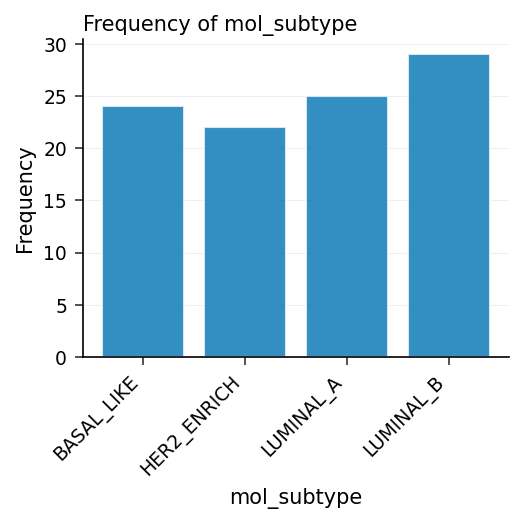

In [3]:
/* --------------------------------------------------------
   Baseline-subtypefordeling og ekspressionsprofiler
   -------------------------------------------------------- */
PROCEDURE FREKVENSER data=work.gene_expr;
    TABLES mol_subtype / nocum;
    MÆRKAT mol_subtype="Molekylær subtype";
    TITEL 'Fordeling af molekylære subtyper';
KØR;

PROCEDURE GENNEMSNIT data=work.gene_expr n mean std;
    KLASSE mol_subtype;
    VARIABEL esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    MÆRKAT mol_subtype="Molekylær subtype"
    esr1_expr="ESR1-ekspression (log2)"
    pgr_expr="PGR-ekspression (log2)"
    erbb2_expr="ERBB2-ekspression (log2)"
    ki67_expr="KI67-ekspression (log2)"
    egfr_expr="EGFR-ekspression (log2)"
    cytokeratin5="Cytokeratin-5 (log2)"
    tp53_mut_load="TP53-mutationsbelastning"
    prolif_score="Proliferationsscore";
    TITEL 'Sammendrag af genekspression efter molekylær subtype';
KØR;

---

In [4]:
/* --------------------------------------------------------
   Kanonisk diskriminantanalyse med MANOVA
   CANONICAL udtrækker diskriminantakser til visualisering.
   MANOVA tester den samlede adskillelse af gennemsnit på tværs af subtyper.
   -------------------------------------------------------- */
PROCEDURE DISCRIM data=work.gene_expr
        METHOD=NORMAL
        pool=TEST
        canonical
        MANOVA
        crossvalidate
        out=work.subtype_canonical
        OUTSTAT=work.subtype_stats;
    KLASSE mol_subtype;
    VARIABEL esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    MÆRKAT mol_subtype="Molekylær subtype"
    esr1_expr="ESR1-ekspression (log2)"
    pgr_expr="PGR-ekspression (log2)"
    erbb2_expr="ERBB2-ekspression (log2)"
    ki67_expr="KI67-ekspression (log2)"
    egfr_expr="EGFR-ekspression (log2)"
    cytokeratin5="Cytokeratin-5 (log2)"
    tp53_mut_load="TP53-mutationsbelastning"
    prolif_score="Proliferationsscore";
    TITEL 'Kanonisk diskriminantanalyse: molekylære tumorsubtyper';
    title2 'MANOVA-test for forskelle i gennemsnitlige ekspressionsprofiler';
KØR;

                                  Sammendrag af genekspression efter molekylær subtype                                  


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Cross-Validation Error Rate: 0.0400
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: Multivariate Statistics:
NOTE:   Wilks' Lambda: 0.0037 (p = 0.000000)
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


---

                                  Sammendrag af genekspression efter molekylær subtype                                  




NOTE: PROC SGPLOT data=work.subtype_canonical

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


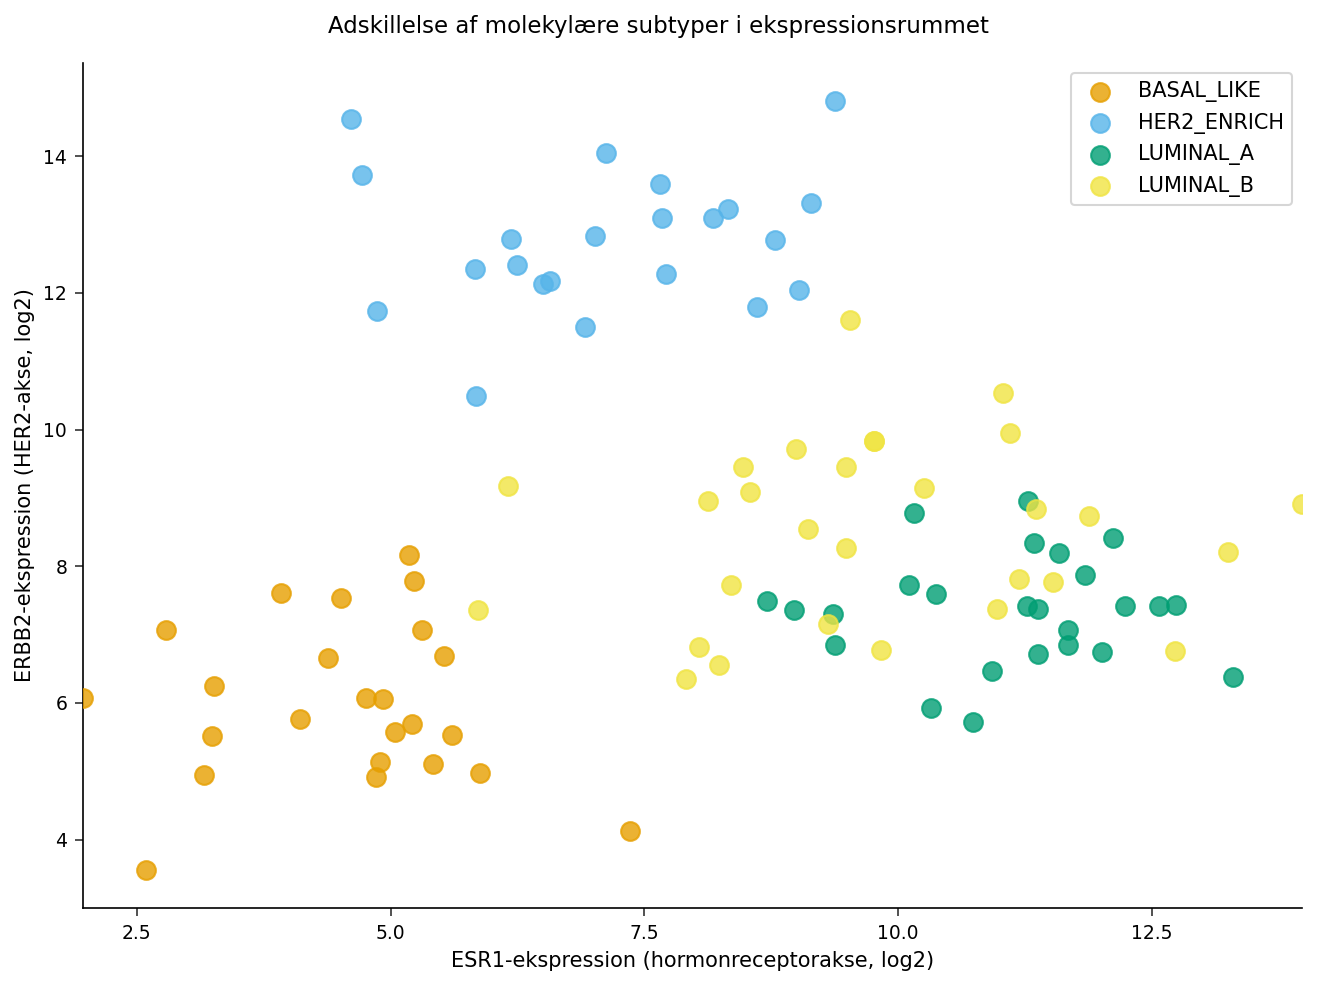

In [5]:
/* --------------------------------------------------------
   Adskillelse af subtyper i ekspressionsrummet
   ESR1 (hormonreceptorakse) vs. ERBB2 (HER2-akse),
   hentet fra diskriminant-OUT=-datasættet.
   -------------------------------------------------------- */
PROCEDURE SGPLOT data=work.subtype_canonical;
    SCATTER x=esr1_expr y=erbb2_expr / GROUP=mol_subtype
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.2;
    XAXIS MÆRKAT='ESR1-ekspression (hormonreceptorakse, log2)';
    YAXIS MÆRKAT='ERBB2-ekspression (HER2-akse, log2)';
    TITEL 'Adskillelse af molekylære subtyper i ekspressionsrummet';
KØR;


In [6]:
/* --------------------------------------------------------
   Klassificér utypede biopsiprøver
   -------------------------------------------------------- */
PROCEDURE DISCRIM data=work.gene_expr
        testdata=work.new_biopsies
        testout=work.classified_biopsies
        METHOD=NORMAL
        pool=TEST
        canonical;
    KLASSE mol_subtype;
    VARIABEL esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    MÆRKAT mol_subtype="Molekylær subtype"
    esr1_expr="ESR1-ekspression (log2)"
    pgr_expr="PGR-ekspression (log2)"
    erbb2_expr="ERBB2-ekspression (log2)"
    ki67_expr="KI67-ekspression (log2)"
    egfr_expr="EGFR-ekspression (log2)"
    cytokeratin5="Cytokeratin-5 (log2)"
    tp53_mut_load="TP53-mutationsbelastning"
    prolif_score="Proliferationsscore";
    TITEL 'Klassifikation af molekylær subtype for nye biopsier';
KØR;

                                  Sammendrag af genekspression efter molekylær subtype                                  


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


                                Forudsagt fordeling af molekylære subtyper: nye biopsier                                

                                                   The FREQ Procedure

Forudsagt molekylær subtype     Frequency    Percent
-----------------------------------------------------
BASAL_LIKE                              7      7.00
HER2_ENRICH                            47     47.00
LUMINAL_A                              10     10.00
LUMINAL_B                              36     36.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq__into_.spec.json
NOTE: PROC FREQ statement used.


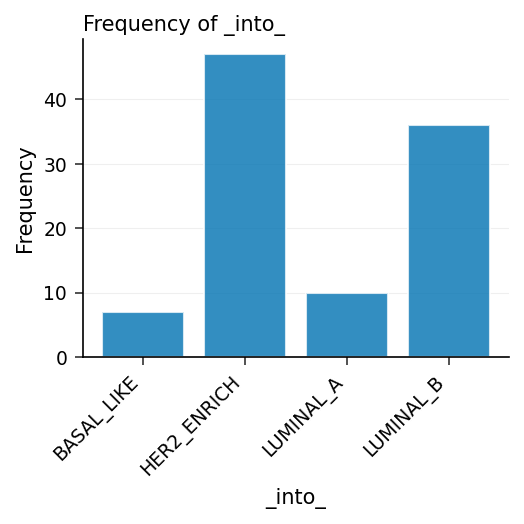

In [7]:
/* --------------------------------------------------------
   Klassifikationsfordeling for nye biopsier
   -------------------------------------------------------- */
PROCEDURE FREKVENSER data=work.classified_biopsies;
    TABLES _into_ / nocum;
    MÆRKAT _into_="Forudsagt molekylær subtype";
    TITEL 'Forudsagt fordeling af molekylære subtyper: nye biopsier';
KØR;

---

### Fortolkning

MANOVA-testen bekræfter en yderst signifikant forskel i de gennemsnitlige genekspressionsprofiler på tværs af de fire molekylære subtyper: Wilks' Lambda = 0.0037 med p < 0.0001, så subtyperne optager tydeligt adskilte områder af det ottedimensionelle markørekspressionsrum. Den adskillelse er synlig i spredningsplottet i ekspressionsrummet, hvor Luminale tumorer ligger højt på ESR1-aksen (hormonreceptor), mens HER2-berigede tumorer skubbes mod toppen af ERBB2-aksen og Basal-lignende tumorer falder mod nederste venstre hjørne på begge. Resubstitutionsklassifikation af de 100 etiketterede tumorer er perfekt (0% tilsyneladende fejl), og leave-one-out-krydsvalidering placerer fejlraten på blot 4% — en ærlig krydsvalideret nøjagtighed på 96%, hvor hver subtype korrekt genfindes i den krydsvaliderede forvekslingsmatrix. Ved at anvende den trænede klassifikator på de 100 uetiketterede biopsier tildeles 47 til HER2-beriget, 36 til Luminal-B, 10 til Luminal-A og 7 til Basal-lignende; hældningen mod HER2-beriget afspejler biopsipanelets forhøjede ERBB2- og proliferationsaflæsninger. Disse subtypebestemmelser styrer valget af behandlingsforløb: endokrin terapi for Luminale tumorer, målrettede anti-HER2-midler for HER2-beriget-gruppen og kemoterapiregimer for Basal-lignende tumorer.


---

In [8]:
/* --------------------------------------------------------
   Eksportér klassificerede biopsier til behandlingsplanlægning
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=work.classified_biopsies
    OUTFILE='classified_biopsy_subtypes.csv'
    DBMS=csv REPLACE;
KØR;

PROCEDURE EKSPORTERE data=work.subtype_canonical
    OUTFILE='canonical_subtype_scores.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=work.classified_biopsies outfile=classified_biopsy_subtypes.csv

NOTE: Exported 100 rows to classified_biopsy_subtypes.csv.
NOTE: PROC EXPORT data=work.subtype_canonical outfile=canonical_subtype_scores.csv

NOTE: Exported 100 rows to canonical_subtype_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>